In [1]:
# ============================================
# 1. 필요한 라이브러리 설치 및 임포트
# ============================================
# !pip install transformers torch scikit-learn pandas numpy

import pandas as pd
import numpy as np
import torch
import json
from torch.optim import AdamW 
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertForSequenceClassification
from transformers import get_linear_schedule_with_warmup
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# GPU 사용 가능 여부 확인
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"사용 디바이스: {device}")

사용 디바이스: cpu


In [2]:
# ============================================
# 2. 데이터 로드 (당신의 데이터로 교체)
# ============================================
#Train data 
with open('C:\\Users\\user\\Documents\\프로젝트\\3차_감성대화data\\감성대화말뭉치(최종데이터)_Training.json', 'r') as f:
    Train_data = json.load(f)

print(f"총 대화 세트 수: {len(Train_data)}")

총 대화 세트 수: 51628


In [3]:
#Validation data 
with open('C:\\Users\\user\\Documents\\프로젝트\\3차_감성대화data\\감성대화말뭉치(최종데이터)_Validation.json', 'r') as f:
    Val_data = json.load(f)

print(f"총 대화 세트 수: {len(Val_data)}")

총 대화 세트 수: 6640


In [4]:
# 특성 추출 함수 - DataFrame 생성

def extract_records(data_list):
    
    records = []
    idx = 0  # 동일한 persona_id 구분용 새로운 인덱스 추가

    for item in tqdm(data_list):
        profile = item.get("profile", {})
        persona_id = profile.get("persona-id")

        # 감정 정보
        emotion_type = profile.get("emotion", {}).get("type")  # 예: E18
        situation_list = profile.get("emotion", {}).get("situation", [])
        situation = next((s for s in situation_list if s.startswith("S")), None)

        # 인적 특성
        human = profile.get("persona", {}).get("human", [])
        age = next((s for s in human if s.startswith("A")), None)
        gender = next((s for s in human if s.startswith("G")), None)

        # 감정 발화문 HS01만 추출
        talk_content = item.get("talk", {}).get("content", {})
        hs01_text = talk_content.get("HS01", "").strip()

        if hs01_text:  # 비어 있지 않으면 저장
            idx += 1
            records.append({
                "index_id": idx,
                "persona_id": persona_id,
                "age": age,
                "gender": gender,
                "emotion_type": emotion_type,
                "situation": situation,
                "text": hs01_text
            })

    return pd.DataFrame(records)

In [5]:
# 훈련데이터 적용

df_train_raw = extract_records(Train_data)
print("DataFrame 크기:", df_train_raw.shape)
print(df_train_raw.head(20))

100%|██████████| 51628/51628 [00:00<00:00, 116979.23it/s]

DataFrame 크기: (51628, 7)
    index_id persona_id  age gender emotion_type situation  \
0          1  Pro_05349  A02    G02          E18       S06   
1          2  Pro_05349  A02    G02          E18       S06   
2          3  Pro_05349  A02    G02          E18       S06   
3          4  Pro_05349  A02    G02          E18       S06   
4          5  Pro_05349  A02    G02          E18       S06   
5          6  Pro_05349  A02    G02          E18       S06   
6          7  Pro_05349  A02    G02          E18       S06   
7          8  Pro_05397  A02    G02          E66       S06   
8          9  Pro_05368  A02    G02          E37       S06   
9         10  Pro_05397  A02    G02          E66       S06   
10        11  Pro_05397  A02    G02          E66       S06   
11        12  Pro_05366  A02    G02          E35       S06   
12        13  Pro_05366  A02    G02          E35       S06   
13        14  Pro_05366  A02    G02          E35       S06   
14        15  Pro_05381  A02    G02          

In [6]:
# 검증데이터 적용

df_val_raw= extract_records(Val_data)
print("DataFrame 크기:", df_val_raw.shape)
print(df_val_raw.head(20))

100%|██████████| 6640/6640 [00:00<00:00, 457806.14it/s]

DataFrame 크기: (6640, 7)
    index_id persona_id  age gender emotion_type situation  \
0          1  Pro_03802  A02    G01          E31       S06   
1          2  Pro_03802  A02    G01          E31       S06   
2          3  Pro_03802  A02    G01          E31       S06   
3          4  Pro_03802  A02    G01          E31       S06   
4          5  Pro_03802  A02    G01          E31       S06   
5          6  Pro_03802  A02    G01          E31       S06   
6          7  Pro_03802  A02    G01          E31       S06   
7          8  Pro_03802  A02    G01          E31       S06   
8          9  Pro_03802  A02    G01          E31       S06   
9         10  Pro_03802  A02    G01          E31       S06   
10        11  Pro_03802  A02    G01          E31       S06   
11        12  Pro_03802  A02    G01          E31       S06   
12        13  Pro_00316  A01    G01          E25       S03   
13        14  Pro_00316  A01    G01          E25       S03   
14        15  Pro_00316  A01    G01          E

In [7]:
print("데이터 확인:")
print(f"Train shape: {df_train_raw.shape}")
print(f"Validation shape: {df_val_raw.shape}")
print(f"\n감정 분포:")
print(df_train_raw['emotion_type'].value_counts())

데이터 확인:
Train shape: (51628, 7)
Validation shape: (6640, 7)

감정 분포:
emotion_type
E37    1229
E13    1054
E24    1002
E27     993
E31     991
E47     984
E18     975
E32     971
E19     969
E20     958
E10     958
E48     953
E22     950
E45     949
E40     937
E11     926
E58     918
E42     911
E44     910
E23     906
E34     901
E43     901
E51     900
E39     899
E56     897
E41     896
E28     896
E30     893
E29     884
E55     883
E17     882
E12     875
E16     873
E52     872
E21     870
E59     870
E38     869
E53     865
E33     864
E49     861
E36     860
E50     859
E54     859
E15     845
E35     842
E46     840
E25     838
E57     833
E26     828
E14     803
E60     660
E64     655
E67     639
E68     634
E61     631
E62     609
E63     597
E69     570
E66     568
E65     563
Name: count, dtype: int64


In [9]:
# 한글컬럼명(EDA용) 매핑 함수

def apply_korean_labels(df):

    age_map = {"A01": "청소년", "A02": "청년", "A03": "중년", "A04": "노년"}
    gender_map = {"G01": "남성", "G02": "여성"}
    situation_map = {
        "S01": "가족관계", "S02": "학업 및 진로", "S03": "학교폭력/따돌림", "S04": "대인관계",
        "S05": "연애·결혼·출산", "S06": "진로·취업·직장", "S07": "대인관계(부부·자녀)",
        "S08": "재정·은퇴·노후준비", "S09": "건강", "S10": "직장·업무 스트레스",
        "S11": "건강·죽음", "S12": "대인관계(노년)", "S13": "재정"
    }
    emotion_map = {
        "E10":"분노", "E11":"툴툴대는", "E12":"좌절한", "E13":"짜증내는", "E14":"방어적인", "E15":"악의적인", 
        "E16":"안달하는", "E17":"구역질 나는", "E18":"노여워하는", "E19":"성가신", "E20":"슬픔", "E21":"실망한", 
        "E22":"비통한", "E23":"후회되는", "E24":"우울한", "E25":"마비된", "E26":"염세적인", "E27":"눈물이 나는", 
        "E28":"낙담한", "E29":"환멸을 느끼는", "E30":"불안", "E31":"두려운", "E32":"스트레스 받는", "E33":"취약한", 
        "E34":"혼란스러운", "E35":"당혹스러운", "E36":"회의적인", "E37":"걱정스러운", "E38":"조심스러운", "E39":"초조한", 
        "E40":"상처", "E41":"질투하는", "E42":"배신당한", "E43":"고립된","E44":"충격 받은", "E45":"가난한, 불우한", "E46":"희생된", 
        "E47":"억울한", "E48":"괴로워하는", "E49":"버려진", "E50":"당황", "E51":"고립된(당황한)", "E52":"남의 시선을 의식하는", "E53":"외로운", "E54":"열등감", "E55":"죄책감의", "E56":"부끄러운", "E57":"혐오스러운", "E58":"한심한", "E59":"혼란스러운(당황한)", 
        "E60":"기쁨", "E61":"감사하는", "E62":"신뢰하는", "E63":"편안한", "E64":"만족스러운", "E65":"흥분", "E66":"느긋", "E67":"안도",
        "E68":"신이 난", "E69":"자신하는"
    }
    emotion_group_map = {
        "anger": ["E10","E11","E12","E13","E14","E15","E16","E17","E18","E19"],
        "sadness": ["E20","E21","E22","E23","E24","E25","E26","E27","E28","E29"],
        "anxiety": ["E30","E31","E32","E33","E34","E35","E36","E37","E38","E39"],
        "hurt": ["E40","E41","E42","E43","E44","E45","E46","E47","E48","E49"],
        "embarrassment": ["E50","E51","E52","E53","E54","E55","E56","E57","E58","E59"],
        "joy": ["E60","E61","E62","E63","E64","E65","E66","E67","E68","E69"]
    }
    
    df = df.copy()
    
    df["age_kr"] = df["age"].map(age_map)
    df["gender_kr"] = df["gender"].map(gender_map)
    df["situation_kr"] = df["situation"].map(situation_map)
    df["emotion_kr"] = df["emotion_type"].map(emotion_map)

    def map_emotion_group(e_code):
        for group, codes in emotion_group_map.items():
            if e_code in codes:
                return group
        return None

    df["emotion_group"] = df["emotion_type"].apply(map_emotion_group)

    return df

In [10]:
# 훈련데이터 적용

df_train = apply_korean_labels(df_train_raw)
df_train.head(10)

,index_id,persona_id,age,gender,emotion_type,situation,text,age_kr,gender_kr,situation_kr,emotion_kr,emotion_group
0,1,Pro_05349,A02,G02,E18,S06,일은 왜 해도 해도 끝이 없을까? 화가 난다.,청년,여성,진로·취업·직장,노여워하는,anger
1,2,Pro_05349,A02,G02,E18,S06,이번 달에 또 급여가 깎였어! 물가는 오르는데 월급만 자꾸 깎이니까 너무 화가 나.,청년,여성,진로·취업·직장,노여워하는,anger
2,3,Pro_05349,A02,G02,E18,S06,회사에 신입이 들어왔는데 말투가 거슬려. 그런 애를 매일 봐야 한다고 생각하니까 스...,청년,여성,진로·취업·직장,노여워하는,anger
3,4,Pro_05349,A02,G02,E18,S06,직장에서 막내라는 이유로 나에게만 온갖 심부름을 시켜. 일도 많은 데 정말 분하고 ...,청년,여성,진로·취업·직장,노여워하는,anger
4,5,Pro_05349,A02,G02,E18,S06,얼마 전 입사한 신입사원이 나를 무시하는 것 같아서 너무 화가 나.,청년,여성,진로·취업·직장,노여워하는,anger
5,6,Pro_05349,A02,G02,E18,S06,직장에 다니고 있지만 시간만 버리는 거 같아. 진지하게 진로에 대한 고민이 생겨.,청년,여성,진로·취업·직장,노여워하는,anger
6,7,Pro_05349,A02,G02,E18,S06,성인인데도 진로를 아직도 못 정했다고 부모님이 노여워하셔. 나도 섭섭해.,청년,여성,진로·취업·직장,노여워하는,anger
7,8,Pro_05397,A02,G02,E66,S06,퇴사한 지 얼마 안 됐지만 천천히 직장을 구해보려고.,청년,여성,진로·취업·직장,느긋,joy
8,9,Pro_05368,A02,G02,E37,S06,졸업반이라서 취업을 생각해야 하는데 지금 너무 느긋해서 이래도 되나 싶어.,청년,여성,진로·취업·직장,걱정스러운,anxiety
9,10,Pro_05397,A02,G02,E66,S06,요즘 직장생활이 너무 편하고 좋은 것 같아!,청년,여성,진로·취업·직장,느긋,joy


In [11]:
# 검증데이터 적용

df_val = apply_korean_labels(df_val_raw)
df_val.head(10)

,index_id,persona_id,age,gender,emotion_type,situation,text,age_kr,gender_kr,situation_kr,emotion_kr,emotion_group
0,1,Pro_03802,A02,G01,E31,S06,이번 프로젝트에서 발표를 하는데 내가 실수하는 바람에 우리 팀이 감점을 받았어. 너...,청년,남성,진로·취업·직장,두려운,anxiety
1,2,Pro_03802,A02,G01,E31,S06,회사에서 중요한 프로젝트를 혼자 하게 됐는데 솔직히 두렵고 무서워.,청년,남성,진로·취업·직장,두려운,anxiety
2,3,Pro_03802,A02,G01,E31,S06,상사가 너무 무섭게 생겨서 친해지는 게 너무 두려워.,청년,남성,진로·취업·직장,두려운,anxiety
3,4,Pro_03802,A02,G01,E31,S06,이번에 힘들게 들어간 첫 직장이거든. 첫 직장이라서 그런지 너무 긴장된다.,청년,남성,진로·취업·직장,두려운,anxiety
4,5,Pro_03802,A02,G01,E31,S06,직장에서 동료들이랑 관계가 안 좋아질까 봐 걱정돼.,청년,남성,진로·취업·직장,두려운,anxiety
5,6,Pro_03802,A02,G01,E31,S06,내가 평소에 말이 좀 험한 편인데 무서운 팀장님 앞에서 말실수할까 봐 걱정이야.,청년,남성,진로·취업·직장,두려운,anxiety
6,7,Pro_03802,A02,G01,E31,S06,내 직급이 낮아서 그런지 회의 시간에 내 의견을 무시하는 경향이 있어서 의견을 제시...,청년,남성,진로·취업·직장,두려운,anxiety
7,8,Pro_03802,A02,G01,E31,S06,부장님께 보고서를 올렸는데 혹시 실수한 거 지적당할까 봐 걱정이야.,청년,남성,진로·취업·직장,두려운,anxiety
8,9,Pro_03802,A02,G01,E31,S06,내일 회사 면접을 보러 가는데 내가 틱 증상이 있어서 불안해. 떨어질까 봐 걱정이야.,청년,남성,진로·취업·직장,두려운,anxiety
9,10,Pro_03802,A02,G01,E31,S06,친구랑 같이 백수였는데 내가 이번에 취업을 하는 바람에 그 친구와 멀어질까 봐 걱정이야.,청년,남성,진로·취업·직장,두려운,anxiety


In [12]:
# 훈련데이터
# 감정별 데이터 개수 및 비율
emotion_counts = df_train["emotion_group"].value_counts().reset_index()
emotion_counts.columns = ["emotion_group", "count"]
emotion_counts["ratio(%)"] = (emotion_counts["count"] / len(df_train) * 100).round(2)

# 감정 리스트 출력
print("감정별 데이터 분포 (훈련데이터)")
display(emotion_counts.sort_values(by="count", ascending=False))

감정별 데이터 분포 (훈련데이터)


,emotion_group,count,ratio(%)
0,anxiety,9319,18.05
1,anger,9160,17.74
2,hurt,9142,17.71
3,sadness,9125,17.67
4,embarrassment,8756,16.96
5,joy,6126,11.87


In [13]:
# 훈련데이터
# 감정별 데이터 개수 및 비율
emotion_counts = df_val["emotion_group"].value_counts().reset_index()
emotion_counts.columns = ["emotion_group", "count"]
emotion_counts["ratio(%)"] = (emotion_counts["count"] / len(df_val) * 100).round(2)

# 감정 리스트 출력
print("감정별 데이터 분포 (훈련데이터)")
display(emotion_counts.sort_values(by="count", ascending=False))

감정별 데이터 분포 (훈련데이터)


,emotion_group,count,ratio(%)
0,anger,1257,18.93
1,joy,1213,18.27
2,anxiety,1112,16.75
3,embarrassment,1048,15.78
4,hurt,1007,15.17
5,sadness,1003,15.11


In [14]:
# ============================================
# 3. 레이블 처리 (emotion_group 사용)
# ============================================

# emotion_group 확인
print("emotion_group 고유값:")
print(df_train['emotion_group'].unique())
print(f"\n데이터 타입: {df_train['emotion_group'].dtype}")

# 고유한 감정 그룹 (이미 'anger', 'sadness' 등의 문자열)
unique_emotions = sorted(df_train['emotion_group'].unique())
print(f"\n감정 그룹 ({len(unique_emotions)}개): {unique_emotions}")

# 문자열을 숫자로 매핑
emotion_to_id = {emotion: idx for idx, emotion in enumerate(unique_emotions)}
id_to_emotion = {idx: emotion for emotion, idx in emotion_to_id.items()}

print(f"\n레이블 매핑:")
print("="*60)
for emotion, idx in emotion_to_id.items():
    count_train = len(df_train[df_train['emotion_group'] == emotion])
    count_val = len(df_val[df_val['emotion_group'] == emotion])
    print(f"  {emotion:15} -> {idx}  (Train: {count_train:5}, Val: {count_val:4})")

# label 컬럼 생성 (문자열 → 숫자)
df_train['label'] = df_train['emotion_group'].map(emotion_to_id)
df_val['label'] = df_val['emotion_group'].map(emotion_to_id)

# 매핑 확인 (NaN이 있으면 문제)
print("\n매핑 결과 확인:")
print(f"Train label 범위: {df_train['label'].min()} ~ {df_train['label'].max()}")
print(f"Val label 범위: {df_val['label'].min()} ~ {df_val['label'].max()}")

if df_train['label'].isna().any():
    print("\n⚠️ 경고: Train에 매핑 실패한 값이 있습니다!")
    print(df_train[df_train['label'].isna()]['emotion_group'].unique())

if df_val['label'].isna().any():
    print("\n⚠️ 경고: Validation에 매핑 실패한 값이 있습니다!")
    print(df_val[df_val['label'].isna()]['emotion_group'].unique())

# num_labels 정의
num_labels = len(emotion_to_id)
print(f"\n✅ 클래스 개수 (num_labels): {num_labels}")

# 분포 확인
print("\n" + "="*60)
print("Train 감정 그룹 분포:")
train_dist = df_train['emotion_group'].value_counts().sort_index()
print(train_dist)

print("\nValidation 감정 그룹 분포:")
val_dist = df_val['emotion_group'].value_counts().sort_index()
print(val_dist)
print("="*60)

# 매핑 사전 출력 (나중에 사용)
print("\n매핑 사전:")
print(f"emotion_to_id = {emotion_to_id}")
print(f"id_to_emotion = {id_to_emotion}")


emotion_group 고유값:
['anger' 'joy' 'anxiety' 'embarrassment' 'sadness' 'hurt']

데이터 타입: object

감정 그룹 (6개): ['anger', 'anxiety', 'embarrassment', 'hurt', 'joy', 'sadness']

레이블 매핑:
  anger           -> 0  (Train:  9160, Val: 1257)
  anxiety         -> 1  (Train:  9319, Val: 1112)
  embarrassment   -> 2  (Train:  8756, Val: 1048)
  hurt            -> 3  (Train:  9142, Val: 1007)
  joy             -> 4  (Train:  6126, Val: 1213)
  sadness         -> 5  (Train:  9125, Val: 1003)

매핑 결과 확인:
Train label 범위: 0 ~ 5
Val label 범위: 0 ~ 5

✅ 클래스 개수 (num_labels): 6

Train 감정 그룹 분포:
emotion_group
anger            9160
anxiety          9319
embarrassment    8756
hurt             9142
joy              6126
sadness          9125
Name: count, dtype: int64

Validation 감정 그룹 분포:
emotion_group
anger            1257
anxiety          1112
embarrassment    1048
hurt             1007
joy              1213
sadness          1003
Name: count, dtype: int64

매핑 사전:
emotion_to_id = {'anger': 0, 'anxiety': 1, 'embarr

# 1st

In [45]:
# ============================================
# 4. ko-BERT 토크나이저 로드
# ============================================
MODEL_NAME = "monologg/kobert"  # 또는 "skt/kobert-base-v1"
tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)

print(f"\n토크나이저 로드 완료: {MODEL_NAME}")

The tokenizer class you load from this checkpoint is not the same type as the class this function is called from. It may result in unexpected tokenization. 
The tokenizer class you load from this checkpoint is 'KoBertTokenizer'. 
The class this function is called from is 'BertTokenizer'.



토크나이저 로드 완료: monologg/kobert


In [46]:
# ============================================
# 5. Dataset 클래스 정의
# ============================================
class EmotionDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]
        
        # 토크나이징
        encoding = self.tokenizer.encode_plus(
            text,
            add_special_tokens=True,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt'
        )
        
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }


In [47]:
# ============================================
# 6. DataLoader 생성
# ============================================
BATCH_SIZE = 16
MAX_LENGTH = 128

train_dataset = EmotionDataset(
    texts=df_train['text'].values,
    labels=df_train['label'].values,
    tokenizer=tokenizer,
    max_length=MAX_LENGTH
)

val_dataset = EmotionDataset(
    texts=df_val['text'].values,
    labels=df_val['label'].values,
    tokenizer=tokenizer,
    max_length=MAX_LENGTH
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print(f"\nDataLoader 생성 완료")
print(f"Train batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")


DataLoader 생성 완료
Train batches: 3227
Validation batches: 415


In [48]:
# ============================================
# 7. 모델 로드
# ============================================
num_labels = len(emotion_to_id)

model = BertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=num_labels
)
model.to(device)

print(f"\n모델 로드 완료: {num_labels}개 클래스")

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at monologg/kobert and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



모델 로드 완료: 6개 클래스


In [49]:
# ============================================
# 8. Optimizer 및 Scheduler 설정
# ============================================
EPOCHS = 3
LEARNING_RATE = 2e-5

optimizer = AdamW(model.parameters(), lr=LEARNING_RATE)

total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=0,
    num_training_steps=total_steps
)

print(f"\nOptimizer 설정 완료")
print(f"Total training steps: {total_steps}")


Optimizer 설정 완료
Total training steps: 9681


In [50]:
# ============================================
# 9. 학습 함수
# ============================================
def train_epoch(model, data_loader, optimizer, scheduler, device):
    model.train()
    losses = []
    correct_predictions = 0
    total_predictions = 0
    
    progress_bar = tqdm(data_loader, desc='Training')
    
    for batch in progress_bar:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        
        # Forward pass
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )
        
        loss = outputs.loss
        logits = outputs.logits
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        
        # 정확도 계산
        _, preds = torch.max(logits, dim=1)
        correct_predictions += torch.sum(preds == labels)
        total_predictions += labels.size(0)
        losses.append(loss.item())
        
        # Progress bar 업데이트
        progress_bar.set_postfix({
            'loss': loss.item(),
            'acc': correct_predictions.double() / total_predictions
        })
    
    return correct_predictions.double() / total_predictions, np.mean(losses)

In [51]:
# ============================================
# 10. 평가 함수
# ============================================
def eval_model(model, data_loader, device):
    model.eval()
    losses = []
    correct_predictions = 0
    total_predictions = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        progress_bar = tqdm(data_loader, desc='Validation')
        
        for batch in progress_bar:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )
            
            loss = outputs.loss
            logits = outputs.logits
            
            _, preds = torch.max(logits, dim=1)
            
            correct_predictions += torch.sum(preds == labels)
            total_predictions += labels.size(0)
            losses.append(loss.item())
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
            progress_bar.set_postfix({
                'loss': loss.item(),
                'acc': correct_predictions.double() / total_predictions
            })
    
    return correct_predictions.double() / total_predictions, np.mean(losses), all_preds, all_labels

In [52]:
# ============================================
# 11. 학습 실행
# ============================================
print("\n" + "="*70)
print("학습 시작!")
print("="*70)

best_val_acc = 0
history = {'train_acc': [], 'train_loss': [], 'val_acc': [], 'val_loss': []}

for epoch in range(EPOCHS):
    print(f"\n{'='*70}")
    print(f"Epoch {epoch + 1}/{EPOCHS}")
    print(f"{'='*70}")
    
    # 학습
    train_acc, train_loss = train_epoch(
        model, train_loader, optimizer, scheduler, device
    )
    
    print(f"\nTrain Loss: {train_loss:.4f}, Train Accuracy: {train_acc:.4f}")
    
    # 검증
    val_acc, val_loss, val_preds, val_labels = eval_model(
        model, val_loader, device
    )
    
    print(f"Val Loss: {val_loss:.4f}, Val Accuracy: {val_acc:.4f}")
    
    # 히스토리 저장
    history['train_acc'].append(train_acc.item())
    history['train_loss'].append(train_loss)
    history['val_acc'].append(val_acc.item())
    history['val_loss'].append(val_loss)
    
    # 최고 성능 모델 저장
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_kobert_emotion_model.pt')
        print(f"✅ 최고 성능 모델 저장! (Val Acc: {val_acc:.4f})")


학습 시작!

Epoch 1/3


Training: 100%|██████████| 3227/3227 [2:21:18<00:00,  2.63s/it, loss=1.82, acc=tensor(0.1760, dtype=torch.float64)]  



Train Loss: 1.7894, Train Accuracy: 0.1760


Validation: 100%|██████████| 415/415 [03:50<00:00,  1.80it/s, loss=1.8, acc=tensor(0.1578, dtype=torch.float64)] 


Val Loss: 1.7994, Val Accuracy: 0.1578
✅ 최고 성능 모델 저장! (Val Acc: 0.1578)

Epoch 2/3


...

Val Loss: 1.8155, Val Accuracy: 0.1675
✅ 최고 성능 모델 저장! (Val Acc: 0.1675)

Epoch 3/3


Training: 100%|██████████| 3227/3227 [2:22:01<00:00,  2.64s/it, loss=1.82, acc=tensor(0.1773, dtype=torch.float64)]  



Train Loss: 1.7839, Train Accuracy: 0.1773


Validation: 100%|██████████| 415/415 [04:06<00:00,  1.68it/s, loss=1.88, acc=tensor(0.1893, dtype=torch.float64)]


Val Loss: 1.8071, Val Accuracy: 0.1893
✅ 최고 성능 모델 저장! (Val Acc: 0.1893)


In [53]:
# ============================================
# 12. 최종 결과 및 평가
# ============================================
print("\n" + "="*70)
print("최종 평가 결과")
print("="*70)

# 최고 모델 로드
model.load_state_dict(torch.load('best_kobert_emotion_model.pt'))
val_acc, val_loss, val_preds, val_labels = eval_model(model, val_loader, device)

# Classification Report
print("\n📊 Classification Report:")
print(classification_report(
    val_labels, 
    val_preds, 
    target_names=[id_to_emotion[i] for i in range(len(id_to_emotion))]
))

# Confusion Matrix
print("\n📊 Confusion Matrix:")
cm = confusion_matrix(val_labels, val_preds)
print(cm)



최종 평가 결과


Validation: 100%|██████████| 415/415 [03:32<00:00,  1.95it/s, loss=1.88, acc=tensor(0.1893, dtype=torch.float64)]


📊 Classification Report:
               precision    recall  f1-score   support

        anger       0.19      1.00      0.32      1257
      anxiety       0.00      0.00      0.00      1112
embarrassment       0.00      0.00      0.00      1048
         hurt       0.00      0.00      0.00      1007
          joy       0.00      0.00      0.00      1213
      sadness       0.00      0.00      0.00      1003

     accuracy                           0.19      6640
    macro avg       0.03      0.17      0.05      6640
 weighted avg       0.04      0.19      0.06      6640


📊 Confusion Matrix:
[[1257    0    0    0    0    0]
 [1112    0    0    0    0    0]
 [1048    0    0    0    0    0]
 [1007    0    0    0    0    0]
 [1213    0    0    0    0    0]
 [1003    0    0    0    0    0]]


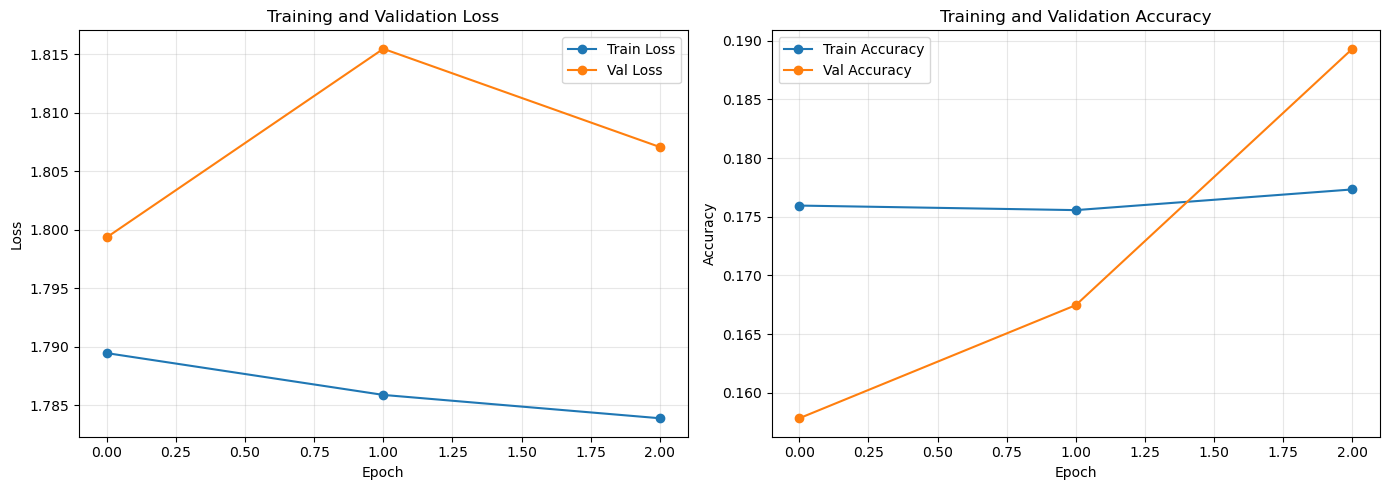


✅ 학습 완료!
최고 Validation Accuracy: 0.1893


In [54]:
# ============================================
# 13. 학습 곡선 시각화
# ============================================
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss
ax1.plot(history['train_loss'], label='Train Loss', marker='o')
ax1.plot(history['val_loss'], label='Val Loss', marker='o')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training and Validation Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy
ax2.plot(history['train_acc'], label='Train Accuracy', marker='o')
ax2.plot(history['val_acc'], label='Val Accuracy', marker='o')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Training and Validation Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✅ 학습 완료!")
print(f"최고 Validation Accuracy: {best_val_acc:.4f}")

In [55]:
# ============================================
# 새로운 텍스트 예측
# ============================================
def predict_emotion(text, model, tokenizer, device, max_length=128):
    model.eval()
    
    encoding = tokenizer.encode_plus(
        text,
        add_special_tokens=True,
        max_length=max_length,
        padding='max_length',
        truncation=True,
        return_attention_mask=True,
        return_tensors='pt'
    )
    
    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)
    
    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        _, preds = torch.max(outputs.logits, dim=1)
        probs = torch.softmax(outputs.logits, dim=1)
    
    return id_to_emotion[preds.item()], probs[0].cpu().numpy()

# 테스트
test_text = "이번에 힘들게 들어간 첫 직장이기도 한데"
emotion, probs = predict_emotion(test_text, model, tokenizer, device)

print(f"\n텍스트: {test_text}")
print(f"예측 감정: {emotion}")
print(f"\n각 감정별 확률:")
for i, prob in enumerate(probs):
    print(f"  {id_to_emotion[i]}: {prob:.4f}")


텍스트: 이번에 힘들게 들어간 첫 직장이기도 한데
예측 감정: anger

각 감정별 확률:
  anger: 0.1812
  anxiety: 0.1791
  embarrassment: 0.1678
  hurt: 0.1770
  joy: 0.1190
  sadness: 0.1759


# 2nd

In [56]:
# ============================================
# 처음부터 다시 학습
# ============================================

print("="*70)
print("🚀 개선된 설정으로 학습 시작")
print("="*70)

# 1. 데이터 로더 재생성 (배치 크기 증가)
BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

# 2. 모델 재로드 (깨끗하게 시작)
model = BertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=num_labels
)
model.to(device)

# 3. Optimizer 설정
LEARNING_RATE = 5e-5  # 증가
EPOCHS = 10

optimizer = AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.01)

# 4. Scheduler
total_steps = len(train_loader) * EPOCHS
warmup_steps = int(0.1 * total_steps)  # 10% warmup

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

print(f"배치 크기: {BATCH_SIZE}")
print(f"에포크: {EPOCHS}")
print(f"학습률: {LEARNING_RATE}")
print(f"Total steps: {total_steps}")
print(f"Warmup steps: {warmup_steps}")

# 5. 학습 시작
best_val_acc = 0
patience = 3
patience_counter = 0
history = {'train_acc': [], 'train_loss': [], 'val_acc': [], 'val_loss': []}

for epoch in range(EPOCHS):
    print(f"\n{'='*70}")
    print(f"Epoch {epoch + 1}/{EPOCHS}")
    print(f"{'='*70}")
    
    # 학습
    train_acc, train_loss = train_epoch(
        model, train_loader, optimizer, scheduler, device
    )
    
    print(f"\n📊 Train - Loss: {train_loss:.4f}, Accuracy: {train_acc:.4f}")
    
    # 검증
    val_acc, val_loss, val_preds, val_labels = eval_model(
        model, val_loader, device
    )
    
    print(f"📊 Val - Loss: {val_loss:.4f}, Accuracy: {val_acc:.4f}")
    
    # 히스토리 저장
    history['train_acc'].append(train_acc.item())
    history['train_loss'].append(train_loss)
    history['val_acc'].append(val_acc.item())
    history['val_loss'].append(val_loss)
    
    # Best model 저장
    if val_acc > best_val_acc:
        improvement = val_acc - best_val_acc
        best_val_acc = val_acc
        patience_counter = 0
        torch.save(model.state_dict(), 'best_kobert_emotion_model.pt')
        print(f"✅ 최고 성능 모델 저장! (Val Acc: {val_acc:.4f}, +{improvement:.4f})")
    else:
        patience_counter += 1
        print(f"⚠️ 성능 개선 없음 ({patience_counter}/{patience})")
        
        if patience_counter >= patience:
            print("\n🛑 Early Stopping 발동")
            break

print(f"\n{'='*70}")
print(f"✅ 학습 완료!")
print(f"{'='*70}")
print(f"최고 Validation Accuracy: {best_val_acc:.4f}")

🚀 개선된 설정으로 학습 시작


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at monologg/kobert and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


배치 크기: 32
에포크: 10
학습률: 5e-05
Total steps: 16140
Warmup steps: 1614

Epoch 1/10


Training: 100%|██████████| 1614/1614 [2:09:11<00:00,  4.80s/it, loss=1.75, acc=tensor(0.1958, dtype=torch.float64)] 



📊 Train - Loss: 1.7741, Accuracy: 0.1958


...

📊 Val - Loss: 1.8129, Accuracy: 0.1517
⚠️ 성능 개선 없음 (2/3)

Epoch 6/10


Training: 100%|██████████| 1614/1614 [2:10:00<00:00,  4.83s/it, loss=1.76, acc=tensor(0.1754, dtype=torch.float64)] 



📊 Train - Loss: 1.7845, Accuracy: 0.1754


Validation: 100%|██████████| 208/208 [04:06<00:00,  1.18s/it, loss=1.88, acc=tensor(0.1511, dtype=torch.float64)]

📊 Val - Loss: 1.8129, Accuracy: 0.1511
⚠️ 성능 개선 없음 (3/3)

🛑 Early Stopping 발동

✅ 학습 완료!
최고 Validation Accuracy: 0.1893


# 3th

In [14]:
# ============================================
# 1. 기존 변수 모두 정리
# ============================================
import gc
import torch

# 메모리 정리
if 'model' in locals():
    del model
if 'optimizer' in locals():
    del optimizer
if 'scheduler' in locals():
    del scheduler

torch.cuda.empty_cache()
gc.collect()

print("✅ 메모리 정리 완료")


✅ 메모리 정리 완료


In [15]:
# ============================================
# 2. 올바른 ko-BERT 설치 및 로드
# ============================================

# 먼저 설치
# !pip install transformers==4.30.0
# !pip install tokenizers
# !pip install sentencepiece

# ko-BERT 모델 선택 (여러 옵션)
# Option 1: monologg/kobert (가장 많이 사용)
# Option 2: skt/kobert-base-v1 (SKT 공식)
# Option 3: kykim/bert-kor-base

MODEL_NAME = "skt/kobert-base-v1"  # 이걸로 변경

print(f"모델: {MODEL_NAME}")

모델: skt/kobert-base-v1


In [16]:
# ============================================
# 3. 토크나이저 및 모델 로드
# ============================================
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"디바이스: {device}")

# 토크나이저 로드
print("\n토크나이저 로드 중...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME )
print("✅ 토크나이저 로드 완료")

# 모델 로드
print("\n모델 로드 중...")
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=6,
    ignore_mismatched_sizes=True  # 중요!
)
model.to(device)
print("✅ 모델 로드 완료")

# 모델 파라미터 확인
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\n전체 파라미터: {total_params:,}")
print(f"학습 가능 파라미터: {trainable_params:,}")

디바이스: cpu

토크나이저 로드 중...
✅ 토크나이저 로드 완료

모델 로드 중...


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at skt/kobert-base-v1 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✅ 모델 로드 완료

전체 파라미터: 92,191,494
학습 가능 파라미터: 92,191,494


In [17]:
# ============================================
# 4. 데이터셋 & 데이터로더 재생성
# ============================================
from torch.utils.data import Dataset, DataLoader

class EmotionDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]
        
        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt'
        )
        
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

# 데이터셋 생성
BATCH_SIZE = 32
MAX_LENGTH = 128

print("\n데이터셋 생성 중...")
train_dataset = EmotionDataset(
    texts=df_train['text'].values,
    labels=df_train['label'].values,
    tokenizer=tokenizer,
    max_length=MAX_LENGTH
)

val_dataset = EmotionDataset(
    texts=df_val['text'].values,
    labels=df_val['label'].values,
    tokenizer=tokenizer,
    max_length=MAX_LENGTH
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"✅ Train batches: {len(train_loader)}")
print(f"✅ Val batches: {len(val_loader)}")



데이터셋 생성 중...
✅ Train batches: 1614
✅ Val batches: 208


In [18]:
# ============================================
# 5. Optimizer & Scheduler (강화된 설정)
# ============================================
from torch.optim import AdamW  # ✅
from transformers import get_linear_schedule_with_warmup

print("✅ Import 성공")

EPOCHS = 10
LEARNING_RATE = 5e-5
WEIGHT_DECAY = 0.01

# Optimizer
optimizer = AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

# Scheduler (Linear만 사용)
total_steps = len(train_loader) * EPOCHS
warmup_steps = int(0.1 * total_steps)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

print(f"\n하이퍼파라미터:")
print(f"  Batch Size: {BATCH_SIZE}")
print(f"  Epochs: {EPOCHS}")
print(f"  Learning Rate: {LEARNING_RATE}")
print(f"  Weight Decay: {WEIGHT_DECAY}")
print(f"  Total Steps: {total_steps}")
print(f"  Warmup Steps: {warmup_steps}")
print(f"  Scheduler: Linear with Warmup")

✅ Import 성공

하이퍼파라미터:
  Batch Size: 32
  Epochs: 10
  Learning Rate: 5e-05
  Weight Decay: 0.01
  Total Steps: 16140
  Warmup Steps: 1614
  Scheduler: Linear with Warmup


In [19]:
# ============================================
# 6. 학습 & 평가 함수
# ============================================
from tqdm import tqdm
import numpy as np

def train_epoch(model, data_loader, optimizer, scheduler, device):
    model.train()
    losses = []
    correct = 0
    total = 0
    
    all_preds = []
    all_labels = []
    
    progress_bar = tqdm(data_loader, desc='Training')
    
    for batch in progress_bar:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        
        optimizer.zero_grad()
        
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )
        
        loss = outputs.loss
        logits = outputs.logits
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        
        _, preds = torch.max(logits, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        losses.append(loss.item())
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        
        progress_bar.set_postfix({
            'loss': f"{loss.item():.4f}",
            'acc': f"{correct/total:.4f}",
            'lr': f"{scheduler.get_last_lr()[0]:.2e}"
        })
    
    # 클래스별 예측 분포
    from collections import Counter
    pred_counter = Counter(all_preds)
    print("\n  [Train] 예측 분포:")
    for i in range(6):
        emotion_name = id_to_emotion[i]
        count = pred_counter.get(i, 0)
        print(f"    {emotion_name}: {count}")
    
    return correct / total, np.mean(losses)

def eval_model(model, data_loader, device):
    model.eval()
    losses = []
    correct = 0
    total = 0
    
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        progress_bar = tqdm(data_loader, desc='Validation')
        
        for batch in progress_bar:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )
            
            loss = outputs.loss
            logits = outputs.logits
            
            _, preds = torch.max(logits, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            losses.append(loss.item())
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
            progress_bar.set_postfix({
                'loss': f"{loss.item():.4f}",
                'acc': f"{correct/total:.4f}"
            })
    
    # 클래스별 예측 분포
    from collections import Counter
    pred_counter = Counter(all_preds)
    print("\n  [Val] 예측 분포:")
    for i in range(6):
        emotion_name = id_to_emotion[i]
        count = pred_counter.get(i, 0)
        print(f"    {emotion_name}: {count}")
    
    return correct / total, np.mean(losses), all_preds, all_labels

In [ ]:
# ============================================
# 7. 학습 시작!
# ============================================
print("\n" + "="*70)
print("🚀 학습 시작!")
print("="*70)

best_val_acc = 0
patience = 5
patience_counter = 0
history = {'train_acc': [], 'train_loss': [], 'val_acc': [], 'val_loss': []}

for epoch in range(EPOCHS):
    print(f"\n{'='*70}")
    print(f"📚 Epoch {epoch + 1}/{EPOCHS}")
    print(f"{'='*70}")
    
    # 학습
    train_acc, train_loss = train_epoch(model, train_loader, optimizer, scheduler, device)
    print(f"\n  ✅ Train Loss: {train_loss:.4f} | Accuracy: {train_acc:.4f}")
    
    # 검증
    val_acc, val_loss, val_preds, val_labels = eval_model(model, val_loader, device)
    print(f"  ✅ Val Loss: {val_loss:.4f} | Accuracy: {val_acc:.4f}")
    
    # 히스토리
    history['train_acc'].append(train_acc)
    history['train_loss'].append(train_loss)
    history['val_acc'].append(val_acc)
    history['val_loss'].append(val_loss)
    
    # Best model 저장
    if val_acc > best_val_acc:
        improvement = val_acc - best_val_acc
        best_val_acc = val_acc
        patience_counter = 0
        torch.save(model.state_dict(), 'best_kobert_emotion_model_v2.pt')
        print(f"\n  🎉 최고 성능! Val Acc: {val_acc:.4f} (+{improvement:.4f})")
    else:
        patience_counter += 1
        print(f"\n  ⏳ 개선 없음 ({patience_counter}/{patience})")
        
        if patience_counter >= patience:
            print(f"\n  🛑 Early Stopping!")
            break

print(f"\n{'='*70}")
print(f"✅ 학습 완료!")
print(f"{'='*70}")
print(f"🏆 최고 Validation Accuracy: {best_val_acc:.4f} ({best_val_acc*100:.2f}%)")


🚀 학습 시작!

📚 Epoch 1/10


Training:   0%|          | 0/1614 [00:00<?, ?it/s]

In [ ]:
# ============================================
# 8. 최종 평가
# ============================================
from sklearn.metrics import classification_report, confusion_matrix

print("\n" + "="*70)
print("📊 최종 평가")
print("="*70)

model.load_state_dict(torch.load('best_kobert_emotion_model_v2.pt'))
val_acc, val_loss, val_preds, val_labels = eval_model(model, val_loader, device)

emotion_names = [id_to_emotion[i] for i in range(6)]

print("\n📈 Classification Report:")
print(classification_report(val_labels, val_preds, target_names=emotion_names))

print("\n📊 Confusion Matrix:")
cm = confusion_matrix(val_labels, val_preds)
print(cm)

# 4th

In [14]:
# ============================================
# 2. 디바이스 설정
# ============================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"디바이스: {device}")

디바이스: cpu


In [15]:
# ============================================
# 3. BertTokenizer & BertForSequenceClassification 로드
# ============================================
MODEL_NAME = "kykim/bert-kor-base"  # 한국어 BERT

print(f"\n모델: {MODEL_NAME}")
print("BertForSequenceClassification 사용")

# BertTokenizer 로드
print("\n[1/2] BertTokenizer 로드 중...")
tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)
print("✅ BertTokenizer 로드 완료")

# BertForSequenceClassification 로드
print("\n[2/2] BertForSequenceClassification 로드 중...")
model = BertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=6  # 6개 감정 클래스
)
model.to(device)
print("✅ BertForSequenceClassification 로드 완료")

# 모델 정보 출력
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\n모델 정보:")
print(f"  - 타입: {type(model).__name__}")
print(f"  - 전체 파라미터: {total_params:,}")
print(f"  - 학습 가능 파라미터: {trainable_params:,}")
print(f"  - 클래스 개수: 6")


모델: kykim/bert-kor-base
BertForSequenceClassification 사용

[1/2] BertTokenizer 로드 중...
✅ BertTokenizer 로드 완료

[2/2] BertForSequenceClassification 로드 중...


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at kykim/bert-kor-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✅ BertForSequenceClassification 로드 완료

모델 정보:
  - 타입: BertForSequenceClassification
  - 전체 파라미터: 118,301,958
  - 학습 가능 파라미터: 118,301,958
  - 클래스 개수: 6


In [16]:
# ============================================
# 4. Dataset 클래스
# ============================================
class EmotionDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]
        
        # BertTokenizer로 토크나이징
        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt'
        )
        
        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'labels': torch.tensor(label, dtype=torch.long)
        }

In [17]:
# ============================================
# 5. DataLoader 생성
# ============================================
BATCH_SIZE = 32
MAX_LENGTH = 128

print("\n데이터셋 생성 중...")
train_dataset = EmotionDataset(
    texts=df_train['text'].values,
    labels=df_train['label'].values,
    tokenizer=tokenizer,
    max_length=MAX_LENGTH
)

val_dataset = EmotionDataset(
    texts=df_val['text'].values,
    labels=df_val['label'].values,
    tokenizer=tokenizer,
    max_length=MAX_LENGTH
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print(f"✅ Train batches: {len(train_loader)}")
print(f"✅ Val batches: {len(val_loader)}")

# 샘플 테스트
print("\n샘플 토크나이징 테스트:")
sample_text = df_train['text'].iloc[0]
sample_tokens = tokenizer(sample_text, return_tensors='pt', padding=True, truncation=True, max_length=128)
print(f"텍스트: {sample_text[:50]}...")
print(f"토큰 shape: {sample_tokens['input_ids'].shape}")
print("✅ 토크나이저 정상 작동")


데이터셋 생성 중...
✅ Train batches: 1614
✅ Val batches: 208

샘플 토크나이징 테스트:
텍스트: 일은 왜 해도 해도 끝이 없을까? 화가 난다....
토큰 shape: torch.Size([1, 12])
✅ 토크나이저 정상 작동


In [18]:
# ============================================
# 6. Optimizer & Scheduler
# ============================================
EPOCHS = 10
LEARNING_RATE = 5e-5
WEIGHT_DECAY = 0.01

optimizer = AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

total_steps = len(train_loader) * EPOCHS
warmup_steps = int(0.1 * total_steps)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

print(f"\n학습 설정:")
print(f"  Batch Size: {BATCH_SIZE}")
print(f"  Max Length: {MAX_LENGTH}")
print(f"  Epochs: {EPOCHS}")
print(f"  Learning Rate: {LEARNING_RATE}")
print(f"  Weight Decay: {WEIGHT_DECAY}")
print(f"  Total Steps: {total_steps}")
print(f"  Warmup Steps: {warmup_steps}")


학습 설정:
  Batch Size: 32
  Max Length: 128
  Epochs: 10
  Learning Rate: 5e-05
  Weight Decay: 0.01
  Total Steps: 16140
  Warmup Steps: 1614


In [19]:
# ============================================
# 7. 학습 함수
# ============================================
def train_epoch(model, data_loader, optimizer, scheduler, device):
    model.train()
    losses = []
    correct = 0
    total = 0
    
    progress_bar = tqdm(data_loader, desc='Training')
    
    for batch in progress_bar:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        
        optimizer.zero_grad()
        
        # BertForSequenceClassification forward
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )
        
        loss = outputs.loss
        logits = outputs.logits
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        
        _, preds = torch.max(logits, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        losses.append(loss.item())
        
        progress_bar.set_postfix({
            'loss': f"{loss.item():.4f}",
            'acc': f"{correct/total:.4f}"
        })
    
    return correct / total, np.mean(losses)

def eval_model(model, data_loader, device):
    model.eval()
    losses = []
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        progress_bar = tqdm(data_loader, desc='Validation')
        
        for batch in progress_bar:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            
            # BertForSequenceClassification forward
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )
            
            loss = outputs.loss
            logits = outputs.logits
            
            _, preds = torch.max(logits, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            losses.append(loss.item())
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
            progress_bar.set_postfix({
                'loss': f"{loss.item():.4f}",
                'acc': f"{correct/total:.4f}"
            })
    
    return correct / total, np.mean(losses), all_preds, all_labels

In [21]:
# ============================================
# 자동 저장 헬퍼 함수
# ============================================
def save_checkpoint(epoch, model, optimizer, scheduler, best_val_acc, 
                   patience_counter, train_loss, train_acc, val_loss, val_acc):
    """체크포인트 저장"""
    os.makedirs('checkpoints', exist_ok=True)
    
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'best_val_acc': best_val_acc,
        'patience_counter': patience_counter,
        'train_loss': train_loss,
        'train_acc': train_acc,
        'val_loss': val_loss,
        'val_acc': val_acc
    }
    
    path = f'checkpoints/checkpoint_epoch_{epoch+1}.pt'
    torch.save(checkpoint, path)
    print(f"💾 저장: {path}")

def load_checkpoint(model, optimizer, scheduler):
    """가장 최근 체크포인트 로드"""
    if not os.path.exists('checkpoints'):
        return 0, 0, 0  # start_epoch, best_val_acc, patience_counter
    
    checkpoint_files = [f for f in os.listdir('checkpoints') 
                       if f.startswith('checkpoint_epoch_')]
    
    if not checkpoint_files:
        return 0, 0, 0
    
    latest = max(checkpoint_files, key=lambda x: int(x.split('_')[2].split('.')[0]))
    path = os.path.join('checkpoints', latest)
    
    checkpoint = torch.load(path)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
    
    print(f"✅ 체크포인트 로드: {path}")
    print(f"   Epoch {checkpoint['epoch']+1}부터 재시작")
    
    return checkpoint['epoch'] + 1, checkpoint['best_val_acc'], checkpoint['patience_counter']


In [22]:
# ============================================
# 8. 학습 시작
# ============================================
print("\n" + "="*70)
print("🚀 BertForSequenceClassification 학습 시작!")
print("="*70)

best_val_acc = 0
patience = 5
patience_counter = 0

for epoch in range(EPOCHS):
    print(f"\n{'='*70}")
    print(f"Epoch {epoch + 1}/{EPOCHS}")
    print(f"{'='*70}")
    
    # 학습
    train_acc, train_loss = train_epoch(
        model, train_loader, optimizer, scheduler, device
    )
    print(f"\n✅ Train Loss: {train_loss:.4f} | Accuracy: {train_acc:.4f}")
    
    # 검증
    val_acc, val_loss, val_preds, val_labels = eval_model(
        model, val_loader, device
    )
    print(f"✅ Val Loss: {val_loss:.4f} | Accuracy: {val_acc:.4f}")
    
    # Best model 저장
    if val_acc > best_val_acc:
        improvement = val_acc - best_val_acc
        best_val_acc = val_acc
        patience_counter = 0
        torch.save(model.state_dict(), 'best_bert_emotion_model.pt')
        print(f"🎉 최고 성능! Val Acc: {val_acc:.4f} (+{improvement:.4f})")
    else:
        patience_counter += 1
        print(f"⏳ 개선 없음 ({patience_counter}/{patience})")
        
        if patience_counter >= patience:
            print("\n🛑 Early Stopping!")
            break

print(f"\n{'='*70}")
print(f"✅ 학습 완료!")
print(f"{'='*70}")
print(f"🏆 최고 Validation Accuracy: {best_val_acc:.4f} ({best_val_acc*100:.2f}%)")


🚀 BertForSequenceClassification 학습 시작!

Epoch 1/10


Training: 100%|██████████| 1614/1614 [2:09:46<00:00,  4.82s/it, loss=1.1494, acc=0.4874] 



✅ Train Loss: 1.2992 | Accuracy: 0.4874


Validation: 100%|██████████| 208/208 [04:03<00:00,  1.17s/it, loss=0.8301, acc=0.6595]


✅ Val Loss: 0.9254 | Accuracy: 0.6595
🎉 최고 성능! Val Acc: 0.6595 (+0.6595)

Epoch 2/10


...

✅ Val Loss: 1.3927 | Accuracy: 0.7453
🎉 최고 성능! Val Acc: 0.7453 (+0.0038)

Epoch 10/10


Training: 100%|██████████| 1614/1614 [2:07:15<00:00,  4.73s/it, loss=0.0145, acc=0.9740] 



✅ Train Loss: 0.0873 | Accuracy: 0.9740


Validation: 100%|██████████| 208/208 [03:57<00:00,  1.14s/it, loss=2.3899, acc=0.7435]

✅ Val Loss: 1.5217 | Accuracy: 0.7435
⏳ 개선 없음 (1/5)

✅ 학습 완료!
🏆 최고 Validation Accuracy: 0.7453 (74.53%)


# 4-1

In [23]:
# ============================================
# 최적 설정 조합
# ============================================


# 1. 하이퍼파라미터 조정
BATCH_SIZE = 48  # 32 → 48
MAX_LENGTH = 128
EPOCHS = 15  # 10 → 15
LEARNING_RATE = 3e-5  # 5e-5 → 3e-5
WEIGHT_DECAY = 0.01

# 2. 모델 로드
MODEL_NAME = "kykim/bert-kor-base"
tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)
model = BertForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=6)
model.to(device)

# 3. DataLoader
train_dataset = EmotionDataset(df_train['text'].values, df_train['label'].values, tokenizer)
val_dataset = EmotionDataset(df_val['text'].values, df_val['label'].values, tokenizer)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

# 4. Optimizer (Layer별 다른 LR)
def get_optimizer_grouped_parameters(model):
    no_decay = ['bias', 'LayerNorm.weight']
    optimizer_grouped_parameters = [
        {
            'params': [p for n, p in model.bert.named_parameters() 
                      if not any(nd in n for nd in no_decay)],
            'weight_decay': 0.01,
            'lr': 2e-5
        },
        {
            'params': [p for n, p in model.bert.named_parameters() 
                      if any(nd in n for nd in no_decay)],
            'weight_decay': 0.0,
            'lr': 2e-5
        },
        {
            'params': model.classifier.parameters(),
            'lr': 5e-5
        }
    ]
    return optimizer_grouped_parameters

optimizer = AdamW(get_optimizer_grouped_parameters(model))

# 5. Scheduler (Warmup 증가)
total_steps = len(train_loader) * EPOCHS
warmup_steps = int(0.15 * total_steps)  # 0.1 → 0.15

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

# 6. Early Stopping
patience = 7  # 5 → 7

print("="*70)
print("🚀 개선된 설정으로 재학습 시작!")
print("="*70)
print(f"Batch Size: {BATCH_SIZE}")
print(f"Epochs: {EPOCHS}")
print(f"Learning Rate: BERT={2e-5}, Classifier={5e-5}")
print(f"Warmup: {warmup_steps} steps ({warmup_steps/total_steps*100:.1f}%)")
print(f"Patience: {patience}")
print("="*70)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at kykim/bert-kor-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


🚀 개선된 설정으로 재학습 시작!
Batch Size: 48
Epochs: 15
Learning Rate: BERT=2e-05, Classifier=5e-05
Warmup: 2421 steps (15.0%)
Patience: 7


In [24]:
# ============================================
# 디버깅: 어디서 멈췄는지 확인
# ============================================

print("\n" + "="*70)
print("🔍 디버깅 시작")
print("="*70)

# 1. DataLoader 확인
print("\n[1/5] DataLoader 확인 중...")
try:
    print(f"Train loader length: {len(train_loader)}")
    print(f"Val loader length: {len(val_loader)}")
    print("✅ DataLoader 정상")
except Exception as e:
    print(f"❌ DataLoader 오류: {e}")

# 2. 첫 배치 가져오기
print("\n[2/5] 첫 배치 가져오기...")
try:
    first_batch = next(iter(train_loader))
    print(f"✅ 배치 shape: {first_batch['input_ids'].shape}")
except Exception as e:
    print(f"❌ 배치 오류: {e}")

# 3. 모델 Forward 테스트
print("\n[3/5] 모델 Forward 테스트...")
try:
    model.eval()
    with torch.no_grad():
        input_ids = first_batch['input_ids'][:2].to(device)
        attention_mask = first_batch['attention_mask'][:2].to(device)
        labels = first_batch['labels'][:2].to(device)
        
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        print(f"✅ Loss: {outputs.loss.item():.4f}")
except Exception as e:
    print(f"❌ Forward 오류: {e}")

# 4. Optimizer 확인
print("\n[4/5] Optimizer 확인...")
try:
    print(f"✅ Optimizer: {type(optimizer).__name__}")
    print(f"✅ Scheduler: {type(scheduler).__name__}")
except Exception as e:
    print(f"❌ Optimizer 오류: {e}")

# 5. 간단한 1 step 학습 테스트
print("\n[5/5] 1 step 학습 테스트...")
try:
    model.train()
    optimizer.zero_grad()
    
    input_ids = first_batch['input_ids'][:2].to(device)
    attention_mask = first_batch['attention_mask'][:2].to(device)
    labels = first_batch['labels'][:2].to(device)
    
    outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
    loss = outputs.loss
    
    loss.backward()
    optimizer.step()
    
    print(f"✅ 학습 1 step 완료! Loss: {loss.item():.4f}")
except Exception as e:
    print(f"❌ 학습 오류: {e}")
    import traceback
    traceback.print_exc()

print("\n" + "="*70)
print("디버깅 완료!")
print("="*70)


🔍 디버깅 시작

[1/5] DataLoader 확인 중...
Train loader length: 1076
Val loader length: 139
✅ DataLoader 정상

[2/5] 첫 배치 가져오기...
✅ 배치 shape: torch.Size([48, 128])

[3/5] 모델 Forward 테스트...
✅ Loss: 1.9899

[4/5] Optimizer 확인...
✅ Optimizer: AdamW
✅ Scheduler: LambdaLR

[5/5] 1 step 학습 테스트...
✅ 학습 1 step 완료! Loss: 2.0245

디버깅 완료!


In [25]:
# ============================================
# Step 1: 모든 준비 (한 번만 실행)
# ============================================
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import BertTokenizer, BertForSequenceClassification
from transformers import get_linear_schedule_with_warmup
from sklearn.metrics import classification_report, confusion_matrix
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ 디바이스: {device}")

# 모델 & 토크나이저 로드
MODEL_NAME = "kykim/bert-kor-base"
tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)
model = BertForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=6)
model.to(device)
print("✅ 모델 로드 완료")

# Dataset 클래스
class EmotionDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]
        
        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt'
        )
        
        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'labels': torch.tensor(label, dtype=torch.long)
        }

# DataLoader
BATCH_SIZE = 48
MAX_LENGTH = 128

train_dataset = EmotionDataset(df_train['text'].values, df_train['label'].values, tokenizer, MAX_LENGTH)
val_dataset = EmotionDataset(df_val['text'].values, df_val['label'].values, tokenizer, MAX_LENGTH)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"✅ DataLoader 완료: Train={len(train_loader)}, Val={len(val_loader)}")

# Optimizer 설정
EPOCHS = 15
LEARNING_RATE = 3e-5
WEIGHT_DECAY = 0.01

# Layer별 다른 Learning Rate
def get_optimizer_grouped_parameters(model):
    no_decay = ['bias', 'LayerNorm.weight']
    optimizer_grouped_parameters = [
        {
            'params': [p for n, p in model.bert.named_parameters() 
                      if not any(nd in n for nd in no_decay)],
            'weight_decay': 0.01,
            'lr': 2e-5
        },
        {
            'params': [p for n, p in model.bert.named_parameters() 
                      if any(nd in n for nd in no_decay)],
            'weight_decay': 0.0,
            'lr': 2e-5
        },
        {
            'params': model.classifier.parameters(),
            'lr': 5e-5
        }
    ]
    return optimizer_grouped_parameters

optimizer = AdamW(get_optimizer_grouped_parameters(model))

total_steps = len(train_loader) * EPOCHS
warmup_steps = int(0.15 * total_steps)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

print("✅ Optimizer & Scheduler 완료")
print(f"\n📋 학습 설정:")
print(f"  - Batch Size: {BATCH_SIZE}")
print(f"  - Epochs: {EPOCHS}")
print(f"  - Learning Rate: BERT=2e-5, Classifier=5e-5")
print(f"  - Total Steps: {total_steps}")
print(f"  - Warmup Steps: {warmup_steps}")
print(f"  - Patience: 7")

✅ 디바이스: cpu


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at kykim/bert-kor-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✅ 모델 로드 완료
✅ DataLoader 완료: Train=1076, Val=139
✅ Optimizer & Scheduler 완료

📋 학습 설정:
  - Batch Size: 48
  - Epochs: 15
  - Learning Rate: BERT=2e-5, Classifier=5e-5
  - Total Steps: 16140
  - Warmup Steps: 2421
  - Patience: 7



🚀 학습 시작!

📚 Epoch 1/15


Epoch 1 Train: 100%|██████████| 1076/1076 [1:58:24<00:00,  6.60s/it, loss=1.0437, acc=0.3907]



✅ Train Loss: 1.4700 | Accuracy: 0.3907


Epoch 1 Val: 100%|██████████| 139/139 [03:49<00:00,  1.65s/it, loss=0.8949, acc=0.6655]


✅ Val Loss: 0.9421 | Accuracy: 0.6655

🎉 최고 성능! Val Acc: 0.6655 (+0.6655)

현재 Best: 0.6655 (66.55%)

📚 Epoch 2/15


...

✅ Val Loss: 1.3142 | Accuracy: 0.7422

⏳ 개선 없음 (2/7)

현재 Best: 0.7431 (74.31%)

📚 Epoch 15/15


Epoch 15 Train: 100%|██████████| 1076/1076 [1:57:15<00:00,  6.54s/it, loss=0.0770, acc=0.9605]



✅ Train Loss: 0.1206 | Accuracy: 0.9605


Epoch 15 Val: 100%|██████████| 139/139 [03:49<00:00,  1.65s/it, loss=1.5821, acc=0.7435]


✅ Val Loss: 1.3385 | Accuracy: 0.7435

🎉 최고 성능! Val Acc: 0.7435 (+0.0005)

현재 Best: 0.7435 (74.35%)

✅ 학습 완료!
🏆 최종 Best Val Accuracy: 0.7435 (74.35%)


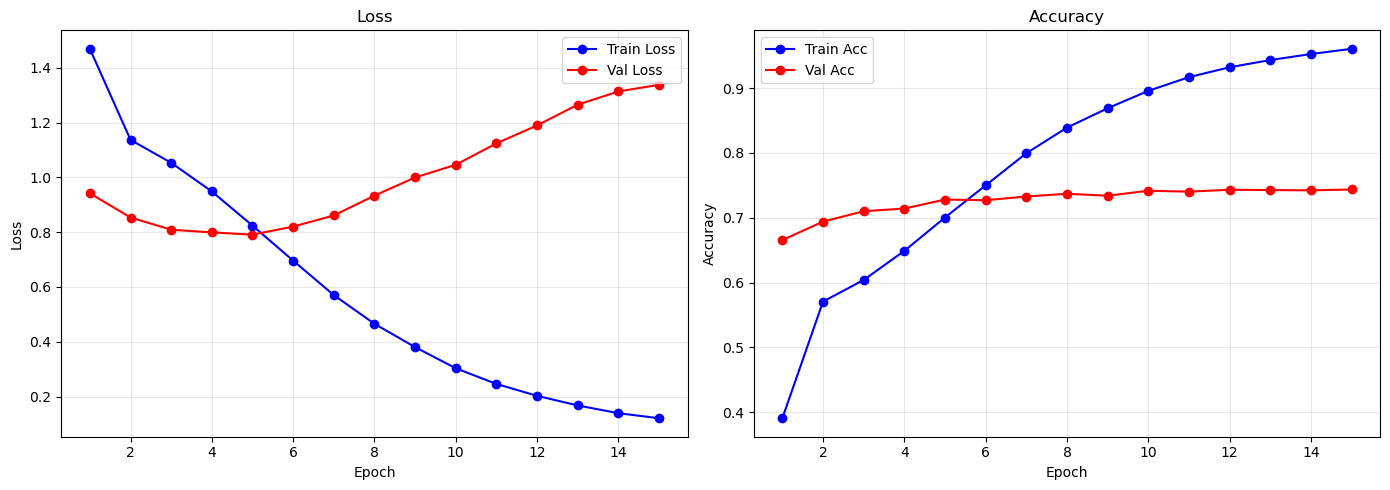

최종 평가: 100%|██████████| 139/139 [03:48<00:00,  1.64s/it]


📊 Classification Report:
               precision    recall  f1-score   support

        anger       0.77      0.74      0.75      1257
      anxiety       0.70      0.70      0.70      1112
embarrassment       0.69      0.70      0.69      1048
         hurt       0.65      0.65      0.65      1007
          joy       0.96      0.93      0.94      1213
      sadness       0.67      0.72      0.69      1003

     accuracy                           0.74      6640
    macro avg       0.74      0.74      0.74      6640
 weighted avg       0.75      0.74      0.74      6640


🎉 완료!


In [26]:
# ============================================
# Step 2: 학습 시작 (시간 오래 걸림)
# ============================================

print("\n" + "="*70)
print("🚀 학습 시작!")
print("="*70)

best_val_acc = 0
patience = 7
patience_counter = 0
history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': []
}

for epoch in range(EPOCHS):
    print(f"\n{'='*70}")
    print(f"📚 Epoch {epoch + 1}/{EPOCHS}")
    print(f"{'='*70}")
    
    # 학습
    model.train()
    train_losses = []
    train_correct = 0
    train_total = 0
    
    train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1} Train")
    
    for batch_idx, batch in enumerate(train_bar):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        
        optimizer.zero_grad()
        
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        logits = outputs.logits
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        
        _, preds = torch.max(logits, dim=1)
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)
        train_losses.append(loss.item())
        
        train_bar.set_postfix({
            'loss': f"{loss.item():.4f}",
            'acc': f"{train_correct/train_total:.4f}"
        })
    
    train_acc = train_correct / train_total
    train_loss = np.mean(train_losses)
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    
    print(f"\n✅ Train Loss: {train_loss:.4f} | Accuracy: {train_acc:.4f}")
    
    # 검증
    model.eval()
    val_losses = []
    val_correct = 0
    val_total = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        val_bar = tqdm(val_loader, desc=f"Epoch {epoch+1} Val")
        
        for batch in val_bar:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            
            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            loss = outputs.loss
            logits = outputs.logits
            
            _, preds = torch.max(logits, dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)
            val_losses.append(loss.item())
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
            val_bar.set_postfix({
                'loss': f"{loss.item():.4f}",
                'acc': f"{val_correct/val_total:.4f}"
            })
    
    val_acc = val_correct / val_total
    val_loss = np.mean(val_losses)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    
    print(f"✅ Val Loss: {val_loss:.4f} | Accuracy: {val_acc:.4f}")
    
    # Best Model 저장
    if val_acc > best_val_acc:
        improvement = val_acc - best_val_acc
        best_val_acc = val_acc
        patience_counter = 0
        torch.save(model.state_dict(), 'best_bert_emotion_model.pt')
        print(f"\n🎉 최고 성능! Val Acc: {val_acc:.4f} (+{improvement:.4f})")
    else:
        patience_counter += 1
        print(f"\n⏳ 개선 없음 ({patience_counter}/{patience})")
        
        if patience_counter >= patience:
            print(f"\n🛑 Early Stopping!")
            break
    
    print(f"\n현재 Best: {best_val_acc:.4f} ({best_val_acc*100:.2f}%)")

print(f"\n{'='*70}")
print(f"✅ 학습 완료!")
print(f"🏆 최종 Best Val Accuracy: {best_val_acc:.4f} ({best_val_acc*100:.2f}%)")
print(f"{'='*70}")

# 학습 곡선
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
epochs_range = range(1, len(history['train_loss']) + 1)

ax1.plot(epochs_range, history['train_loss'], 'b-', label='Train Loss', marker='o')
ax1.plot(epochs_range, history['val_loss'], 'r-', label='Val Loss', marker='o')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(epochs_range, history['train_acc'], 'b-', label='Train Acc', marker='o')
ax2.plot(epochs_range, history['val_acc'], 'r-', label='Val Acc', marker='o')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=300)
plt.show()

# 최종 평가
model.load_state_dict(torch.load('best_bert_emotion_model.pt'))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for batch in tqdm(val_loader, desc="최종 평가"):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        _, preds = torch.max(outputs.logits, dim=1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

emotion_names = [id_to_emotion[i] for i in range(6)]
print("\n📊 Classification Report:")
print(classification_report(all_labels, all_preds, target_names=emotion_names))

print("\n🎉 완료!")

# 5

In [28]:
# ============================================
# KoELECTRA 모델 (BERT보다 빠르고 성능 좋음)
# ============================================
from transformers import ElectraTokenizer, ElectraForSequenceClassification

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 모델 선택
MODEL_NAME = "beomi/KcELECTRA-base"  # 또는 "monologg/koelectra-base-v3"

print(f"모델: {MODEL_NAME}")

# 토크나이저 & 모델
tokenizer = ElectraTokenizer.from_pretrained(MODEL_NAME, cache_dir='./model_cache' )
model = ElectraForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=6)
model.to(device)

print("✅ KoELECTRA 로드 완료")

# Dataset (동일)
class EmotionDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]
        
        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt'
        )
        
        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'labels': torch.tensor(label, dtype=torch.long)
        }

# DataLoader
BATCH_SIZE = 48
train_dataset = EmotionDataset(df_train['text'].values, df_train['label'].values, tokenizer)
val_dataset = EmotionDataset(df_val['text'].values, df_val['label'].values, tokenizer)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Optimizer
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup

EPOCHS = 10
LEARNING_RATE = 5e-5

optimizer = AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.01)

total_steps = len(train_loader) * EPOCHS
warmup_steps = int(0.1 * total_steps)

scheduler = get_linear_schedule_with_warmup(optimizer, warmup_steps, total_steps)

print("✅ 준비 완료!")


모델: beomi/KcELECTRA-base


tokenizer_config.json:   0%|          | 0.00/288 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/514 [00:00<?, ?B/s]

The tokenizer class you load from this checkpoint is not the same type as the class this function is called from. It may result in unexpected tokenization. 
The tokenizer class you load from this checkpoint is 'PreTrainedTokenizerFast'. 
The class this function is called from is 'ElectraTokenizer'.


TypeError: _path_isfile: path should be string, bytes, os.PathLike or integer, not NoneType

In [29]:
# ============================================
# Step 1: 환경 초기화 및 import
# ============================================
import torch
import pandas as pd
import numpy as np
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# 디바이스 설정
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ 디바이스: {device}")


✅ 디바이스: cpu


In [30]:
# ============================================
# Step 2: transformers 라이브러리 확인
# ============================================
try:
    import transformers
    print(f"✅ transformers 버전: {transformers.__version__}")
except:
    print("❌ transformers 설치 필요")
    print("실행: !pip install transformers")


✅ transformers 버전: 4.57.1


In [31]:
# ============================================
# Step 3: 모델 명시적 import 및 로드
# ============================================
from transformers import (
    ElectraTokenizer, 
    ElectraForSequenceClassification,
    get_linear_schedule_with_warmup
)

# 🔥 중요: 모델 이름 명시적으로 문자열로 지정
MODEL_NAME = "beomi/KcELECTRA-base"

print(f"\n모델 이름: '{MODEL_NAME}'")
print(f"타입: {type(MODEL_NAME)}")


모델 이름: 'beomi/KcELECTRA-base'
타입: <class 'str'>


In [32]:
# ============================================
# Step 4: 토크나이저 로드 (상세 에러 처리)
# ============================================
print("\n[1/2] 토크나이저 다운로드 중...")

try:
    tokenizer = ElectraTokenizer.from_pretrained(
        MODEL_NAME,
        cache_dir='./model_cache'  # 캐시 디렉토리 명시
    )
    print("✅ 토크나이저 로드 성공!")
    
except Exception as e:
    print(f"❌ 토크나이저 로드 실패: {e}")
    print("\n해결 방법 시도 중...")
    
    # 대안 1: 캐시 삭제 후 재시도
    import os
    import shutil
    if os.path.exists('./model_cache'):
        shutil.rmtree('./model_cache')
        print("캐시 삭제 완료")
    
    # 대안 2: 다른 방법으로 로드
    try:
        from transformers import AutoTokenizer
        tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
        print("✅ AutoTokenizer로 로드 성공!")
    except Exception as e2:
        print(f"❌ 여전히 실패: {e2}")
        
        # 대안 3: 다른 모델 시도
        print("\n대체 모델로 전환...")
        MODEL_NAME = "monologg/koelectra-base-v3"
        print(f"새 모델: {MODEL_NAME}")
        tokenizer = ElectraTokenizer.from_pretrained(MODEL_NAME)
        print("✅ 대체 모델 토크나이저 로드 성공!")


[1/2] 토크나이저 다운로드 중...


The tokenizer class you load from this checkpoint is not the same type as the class this function is called from. It may result in unexpected tokenization. 
The tokenizer class you load from this checkpoint is 'PreTrainedTokenizerFast'. 
The class this function is called from is 'ElectraTokenizer'.


❌ 토크나이저 로드 실패: _path_isfile: path should be string, bytes, os.PathLike or integer, not NoneType

해결 방법 시도 중...
캐시 삭제 완료
✅ AutoTokenizer로 로드 성공!


In [33]:
# ============================================
# Step 5: 모델 로드 (상세 에러 처리)
# ============================================
print("\n[2/2] 모델 다운로드 중...")

try:
    model = ElectraForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=6,
        cache_dir='./model_cache'
    )
    model.to(device)
    print("✅ 모델 로드 성공!")
    
    # 모델 정보
    total_params = sum(p.numel() for p in model.parameters())
    print(f"총 파라미터: {total_params:,}")
    
except Exception as e:
    print(f"❌ 모델 로드 실패: {e}")
    print("\n상세 오류 정보:")
    import traceback
    traceback.print_exc()


[2/2] 모델 다운로드 중...


config.json:   0%|          | 0.00/514 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

Some weights of ElectraForSequenceClassification were not initialized from the model checkpoint at beomi/KcELECTRA-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✅ 모델 로드 성공!
총 파라미터: 109,085,958


In [34]:
# ============================================
# Step 6: Dataset 클래스
# ============================================
class EmotionDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]
        
        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt'
        )
        
        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'labels': torch.tensor(label, dtype=torch.long)
        }

In [36]:
# ============================================
# Step 7: DataLoader 생성
# ============================================
BATCH_SIZE = 48
MAX_LENGTH = 128

print("\n데이터셋 생성 중...")
train_dataset = EmotionDataset(
    df_train['text'].values,
    df_train['label'].values,
    tokenizer,
    MAX_LENGTH
)

val_dataset = EmotionDataset(
    df_val['text'].values,
    df_val['label'].values,
    tokenizer,
    MAX_LENGTH
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"✅ Train batches: {len(train_loader)}")
print(f"✅ Val batches: {len(val_loader)}")


데이터셋 생성 중...
✅ Train batches: 1076
✅ Val batches: 139


In [37]:
# ============================================
# Step 8: Optimizer & Scheduler
# ============================================
EPOCHS = 10
LEARNING_RATE = 5e-5
WEIGHT_DECAY = 0.01

optimizer = AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

total_steps = len(train_loader) * EPOCHS
warmup_steps = int(0.1 * total_steps)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

print("\n" + "="*70)
print("✅✅✅ 모든 준비 완료!")
print("="*70)
print(f"Model: {MODEL_NAME}")
print(f"Batch Size: {BATCH_SIZE}")
print(f"Epochs: {EPOCHS}")
print(f"Learning Rate: {LEARNING_RATE}")
print(f"Device: {device}")
print("="*70)


✅✅✅ 모든 준비 완료!
Model: beomi/KcELECTRA-base
Batch Size: 48
Epochs: 10
Learning Rate: 5e-05
Device: cpu


In [39]:
# ============================================
# 로드 테스트
# ============================================
test_text = "이번에 힘들게 들어간 첫 직장"

# 토크나이저 테스트
tokens = tokenizer(test_text, return_tensors='pt')
print(f"✅ 토크나이저 정상: {tokens['input_ids'].shape}")

# 모델 테스트
model.eval()
with torch.no_grad():
    test_input = tokens['input_ids'].to(device)
    test_mask = tokens['attention_mask'].to(device)
    outputs = model(input_ids=test_input, attention_mask=test_mask)
    print(f"✅ 모델 정상: {outputs.logits.shape}")

print("\n🎉 모든 테스트 통과!")

✅ 토크나이저 정상: torch.Size([1, 5])
✅ 모델 정상: torch.Size([1, 6])

🎉 모든 테스트 통과!


In [44]:
# ============================================
# KoELECTRA 모델 (BERT보다 빠르고 성능 좋음)
# ============================================
from transformers import AutoTokenizer, AutoModelForSequenceClassification

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 모델 선택
MODEL_NAME = "beomi/KcELECTRA-base"  # 또는 "monologg/koelectra-base-v3"

print(f"모델: {MODEL_NAME}")

# 토크나이저 & 모델
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=6)
model.to(device)

print("✅ KoELECTRA 로드 완료")

# Dataset (동일)
class EmotionDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]
        
        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt'
        )
        
        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'labels': torch.tensor(label, dtype=torch.long)
        }

# DataLoader
BATCH_SIZE = 48
train_dataset = EmotionDataset(df_train['text'].values, df_train['label'].values, tokenizer)
val_dataset = EmotionDataset(df_val['text'].values, df_val['label'].values, tokenizer)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Optimizer
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup

EPOCHS = 10
LEARNING_RATE = 5e-5

optimizer = AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.01)

total_steps = len(train_loader) * EPOCHS
warmup_steps = int(0.1 * total_steps)

scheduler = get_linear_schedule_with_warmup(optimizer, warmup_steps, total_steps)

print("✅ 준비 완료!")

모델: beomi/KcELECTRA-base


Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

Some weights of ElectraForSequenceClassification were not initialized from the model checkpoint at beomi/KcELECTRA-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✅ KoELECTRA 로드 완료
✅ 준비 완료!


In [43]:
print(MODEL_NAME)

beomi/KcELECTRA-base


In [45]:
from tqdm import tqdm
import numpy as np

print("\n" + "="*70)
print(f"🚀 {MODEL_NAME} 학습 시작!")
print("="*70)

best_val_acc = 0
patience = 7
patience_counter = 0

for epoch in range(EPOCHS):
    print(f"\n{'='*70}")
    print(f"Epoch {epoch + 1}/{EPOCHS}")
    print(f"{'='*70}")
    
    # 학습
    model.train()
    train_losses = []
    train_correct = 0
    train_total = 0
    
    train_bar = tqdm(train_loader, desc="Train")
    
    for batch in train_bar:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        
        optimizer.zero_grad()
        
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )
        
        loss = outputs.loss
        logits = outputs.logits
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        
        _, preds = torch.max(logits, dim=1)
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)
        train_losses.append(loss.item())
        
        train_bar.set_postfix({
            'loss': f"{loss.item():.4f}",
            'acc': f"{train_correct/train_total:.4f}"
        })
    
    train_acc = train_correct / train_total
    train_loss = np.mean(train_losses)
    
    print(f"\n✅ Train Loss: {train_loss:.4f} | Accuracy: {train_acc:.4f}")
    
    # 검증
    model.eval()
    val_losses = []
    val_correct = 0
    val_total = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        val_bar = tqdm(val_loader, desc="Val")
        
        for batch in val_bar:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )
            
            loss = outputs.loss
            logits = outputs.logits
            
            _, preds = torch.max(logits, dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)
            val_losses.append(loss.item())
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
            val_bar.set_postfix({
                'loss': f"{loss.item():.4f}",
                'acc': f"{val_correct/val_total:.4f}"
            })
    
    val_acc = val_correct / val_total
    val_loss = np.mean(val_losses)
    
    print(f"✅ Val Loss: {val_loss:.4f} | Accuracy: {val_acc:.4f}")
    
    # Best model 저장
    if val_acc > best_val_acc:
        improvement = val_acc - best_val_acc
        best_val_acc = val_acc
        patience_counter = 0
        torch.save(model.state_dict(), 'best_roberta_model.pt')
        print(f"\n🎉 최고 성능! Val Acc: {val_acc:.4f} (+{improvement:.4f})")
    else:
        patience_counter += 1
        print(f"\n⏳ 개선 없음 ({patience_counter}/{patience})")
        
        if patience_counter >= patience:
            print("\n🛑 Early Stopping!")
            break
    
    print(f"\n현재 Best: {best_val_acc:.4f} ({best_val_acc*100:.2f}%)")

print(f"\n{'='*70}")
print(f"✅ 학습 완료!")
print(f"🏆 최종 Best Val Accuracy: {best_val_acc:.4f} ({best_val_acc*100:.2f}%)")
print(f"{'='*70}")


🚀 beomi/KcELECTRA-base 학습 시작!

Epoch 1/10


Train: 100%|██████████| 1076/1076 [1:57:53<00:00,  6.57s/it, loss=1.0812, acc=0.4327]



✅ Train Loss: 1.4186 | Accuracy: 0.4327


Val: 100%|██████████| 139/139 [03:59<00:00,  1.72s/it, loss=0.8919, acc=0.6682]


✅ Val Loss: 0.9344 | Accuracy: 0.6682

🎉 최고 성능! Val Acc: 0.6682 (+0.6682)

현재 Best: 0.6682 (66.82%)

Epoch 2/10


...

✅ Val Loss: 1.2899 | Accuracy: 0.7370

🎉 최고 성능! Val Acc: 0.7370 (+0.0042)

현재 Best: 0.7370 (73.70%)

Epoch 10/10


Train: 100%|██████████| 1076/1076 [1:59:39<00:00,  6.67s/it, loss=0.0778, acc=0.9616]



✅ Train Loss: 0.1302 | Accuracy: 0.9616


Val: 100%|██████████| 139/139 [04:03<00:00,  1.75s/it, loss=1.3577, acc=0.7328]

✅ Val Loss: 1.3686 | Accuracy: 0.7328

⏳ 개선 없음 (1/7)

현재 Best: 0.7370 (73.70%)

✅ 학습 완료!
🏆 최종 Best Val Accuracy: 0.7370 (73.70%)


# 6

In [46]:
# ============================================
# Step 2: KLUE RoBERTa 로드
# ============================================
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup
)

MODEL_NAME = "klue/roberta-base"

print(f"\n모델: {MODEL_NAME}")
print("다운로드 중... (처음엔 시간이 걸릴 수 있습니다)")

try:
    # 토크나이저 로드
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    print("✅ 토크나이저 로드 완료")
    
    # 모델 로드
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=6
    )
    model.to(device)
    print("✅ 모델 로드 완료")
    
    # 모델 정보
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"\n모델 정보:")
    print(f"  - 전체 파라미터: {total_params:,}")
    print(f"  - 학습 가능: {trainable_params:,}")
    
except Exception as e:
    print(f"❌ 오류 발생: {e}")
    print("\n대체 모델로 전환...")
    
    # 대체 옵션들
    alternatives = [
        "klue/roberta-small",  # 더 작은 버전
        "beomi/KcELECTRA-base",  # KoELECTRA
        "skt/kobert-base-v1"  # KoBERT
    ]
    
    for alt_model in alternatives:
        try:
            print(f"시도 중: {alt_model}")
            MODEL_NAME = alt_model
            tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
            model = AutoModelForSequenceClassification.from_pretrained(
                MODEL_NAME,
                num_labels=6
            )
            model.to(device)
            print(f"✅ {MODEL_NAME} 로드 성공!")
            break
        except:
            continue


모델: klue/roberta-base
다운로드 중... (처음엔 시간이 걸릴 수 있습니다)


tokenizer_config.json:   0%|          | 0.00/375 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/173 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/546 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/443M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at klue/roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✅ 모델 로드 완료

모델 정보:
  - 전체 파라미터: 110,622,726
  - 학습 가능: 110,622,726


In [47]:
# ============================================
# Step 3: Dataset 클래스
# ============================================
class EmotionDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]
        
        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt'
        )
        
        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'labels': torch.tensor(label, dtype=torch.long)
        }

In [48]:
# ============================================
# Step 4: DataLoader 생성
# ============================================
BATCH_SIZE = 32  # RoBERTa는 메모리를 많이 사용하므로 32로 시작
MAX_LENGTH = 128

print("\n데이터셋 생성 중...")
train_dataset = EmotionDataset(
    df_train['text'].values,
    df_train['label'].values,
    tokenizer,
    MAX_LENGTH
)

val_dataset = EmotionDataset(
    df_val['text'].values,
    df_val['label'].values,
    tokenizer,
    MAX_LENGTH
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"✅ Train batches: {len(train_loader)}")
print(f"✅ Val batches: {len(val_loader)}")


데이터셋 생성 중...
✅ Train batches: 1614
✅ Val batches: 208


In [49]:
# ============================================
# Step 5: Optimizer & Scheduler (최적화)
# ============================================
EPOCHS = 15
LEARNING_RATE = 2e-5  # RoBERTa는 낮은 LR 선호
WEIGHT_DECAY = 0.01

# Layer별 차등 Learning Rate (성능 향상)
def get_optimizer_grouped_parameters(model):
    no_decay = ['bias', 'LayerNorm.weight', 'LayerNorm.bias']
    
    optimizer_grouped_parameters = [
        # RoBERTa encoder (낮은 LR)
        {
            'params': [p for n, p in model.roberta.named_parameters() 
                      if not any(nd in n for nd in no_decay)],
            'weight_decay': 0.01,
            'lr': LEARNING_RATE * 0.5
        },
        {
            'params': [p for n, p in model.roberta.named_parameters() 
                      if any(nd in n for nd in no_decay)],
            'weight_decay': 0.0,
            'lr': LEARNING_RATE * 0.5
        },
        # Classifier (높은 LR)
        {
            'params': model.classifier.parameters(),
            'weight_decay': 0.01,
            'lr': LEARNING_RATE * 2.0
        }
    ]
    
    return optimizer_grouped_parameters

optimizer = AdamW(
    get_optimizer_grouped_parameters(model),
    eps=1e-8
)

total_steps = len(train_loader) * EPOCHS
warmup_steps = int(0.1 * total_steps)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

print("\n" + "="*70)
print("🚀 KLUE RoBERTa 학습 설정")
print("="*70)
print(f"Model: {MODEL_NAME}")
print(f"Batch Size: {BATCH_SIZE}")
print(f"Max Length: {MAX_LENGTH}")
print(f"Epochs: {EPOCHS}")
print(f"Learning Rate:")
print(f"  - RoBERTa Encoder: {LEARNING_RATE*0.5:.2e}")
print(f"  - Classifier: {LEARNING_RATE*2.0:.2e}")
print(f"Total Steps: {total_steps}")
print(f"Warmup Steps: {warmup_steps} ({warmup_steps/total_steps*100:.1f}%)")
print(f"Weight Decay: {WEIGHT_DECAY}")
print("="*70)


🚀 KLUE RoBERTa 학습 설정
Model: klue/roberta-base
Batch Size: 32
Max Length: 128
Epochs: 15
Learning Rate:
  - RoBERTa Encoder: 1.00e-05
  - Classifier: 4.00e-05
Total Steps: 24210
Warmup Steps: 2421 (10.0%)
Weight Decay: 0.01


In [50]:
# ============================================
# Step 6: 학습 루프
# ============================================
print("\n🚀 학습 시작!")

best_val_acc = 0
patience = 7
patience_counter = 0
history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': []
}

for epoch in range(EPOCHS):
    print(f"\n{'='*70}")
    print(f"📚 Epoch {epoch + 1}/{EPOCHS}")
    print(f"{'='*70}")
    
    # ============================================
    # 학습
    # ============================================
    model.train()
    train_losses = []
    train_correct = 0
    train_total = 0
    
    train_bar = tqdm(train_loader, desc="Train")
    
    for batch in train_bar:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        
        optimizer.zero_grad()
        
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )
        
        loss = outputs.loss
        logits = outputs.logits
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        
        _, preds = torch.max(logits, dim=1)
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)
        train_losses.append(loss.item())
        
        train_bar.set_postfix({
            'loss': f"{loss.item():.4f}",
            'acc': f"{train_correct/train_total:.4f}",
            'lr': f"{scheduler.get_last_lr()[0]:.2e}"
        })
    
    train_acc = train_correct / train_total
    train_loss = np.mean(train_losses)
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    
    print(f"\n✅ Train Loss: {train_loss:.4f} | Accuracy: {train_acc:.4f}")
    
    # ============================================
    # 검증
    # ============================================
    model.eval()
    val_losses = []
    val_correct = 0
    val_total = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        val_bar = tqdm(val_loader, desc="Val")
        
        for batch in val_bar:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )
            
            loss = outputs.loss
            logits = outputs.logits
            
            _, preds = torch.max(logits, dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)
            val_losses.append(loss.item())
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
            val_bar.set_postfix({
                'loss': f"{loss.item():.4f}",
                'acc': f"{val_correct/val_total:.4f}"
            })
    
    val_acc = val_correct / val_total
    val_loss = np.mean(val_losses)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    
    print(f"✅ Val Loss: {val_loss:.4f} | Accuracy: {val_acc:.4f}")
    
    # ============================================
    # Best Model 저장
    # ============================================
    if val_acc > best_val_acc:
        improvement = val_acc - best_val_acc
        best_val_acc = val_acc
        patience_counter = 0
        
        torch.save(model.state_dict(), 'best_roberta_model.pt')
        print(f"\n🎉 최고 성능 갱신! Val Acc: {val_acc:.4f} (+{improvement:.4f})")
        
        # 클래스별 예측 분포
        from collections import Counter
        pred_dist = Counter(all_preds)
        label_dist = Counter(all_labels)
        
        print("\n클래스별 분포:")
        for i in range(6):
            emotion = id_to_emotion[i]
            pred_count = pred_dist.get(i, 0)
            label_count = label_dist.get(i, 0)
            print(f"  {emotion}: 예측={pred_count}, 실제={label_count}")
    else:
        patience_counter += 1
        print(f"\n⏳ 성능 개선 없음 ({patience_counter}/{patience})")
        
        if patience_counter >= patience:
            print(f"\n🛑 Early Stopping! (Epoch {epoch+1})")
            break
    
    print(f"\n현재 Best Val Acc: {best_val_acc:.4f} ({best_val_acc*100:.2f}%)")



🚀 학습 시작!

📚 Epoch 1/15


Train: 100%|██████████| 1614/1614 [2:08:12<00:00,  4.77s/it, loss=1.4519, acc=0.4248, lr=6.67e-06] 



✅ Train Loss: 1.4022 | Accuracy: 0.4248


Val: 100%|██████████| 208/208 [04:04<00:00,  1.17s/it, loss=0.8112, acc=0.6780]


✅ Val Loss: 0.8982 | Accuracy: 0.6780

🎉 최고 성능 갱신! Val Acc: 0.6780 (+0.6780)

클래스별 분포:
  anger: 예측=1026, 실제=1257
  anxiety: 예측=1385, 실제=1112
  embarrassment: 예측=902, 실제=1048
  hurt: 예측=1278, 실제=1007
  joy: 예측=1191, 실제=1213
  sadness: 예측=858, 실제=1003

현재 Best Val Acc: 0.6780 (67.80%)

📚 Epoch 2/15


...

✅ Val Loss: 1.2355 | Accuracy: 0.7340

⏳ 성능 개선 없음 (3/7)

현재 Best Val Acc: 0.7364 (73.64%)

📚 Epoch 15/15


Train: 100%|██████████| 1614/1614 [1:59:00<00:00,  4.42s/it, loss=0.1924, acc=0.9238, lr=0.00e+00]



✅ Train Loss: 0.2231 | Accuracy: 0.9238


Val: 100%|██████████| 208/208 [03:49<00:00,  1.10s/it, loss=2.1028, acc=0.7383]


✅ Val Loss: 1.2537 | Accuracy: 0.7383

🎉 최고 성능 갱신! Val Acc: 0.7383 (+0.0018)

클래스별 분포:
  anger: 예측=1228, 실제=1257
  anxiety: 예측=1049, 실제=1112
  embarrassment: 예측=1148, 실제=1048
  hurt: 예측=1003, 실제=1007
  joy: 예측=1168, 실제=1213
  sadness: 예측=1044, 실제=1003

현재 Best Val Acc: 0.7383 (73.83%)



✅ 학습 완료!
🏆 최종 Best Validation Accuracy: 0.7383 (73.83%)
📊 학습된 Epochs: 15


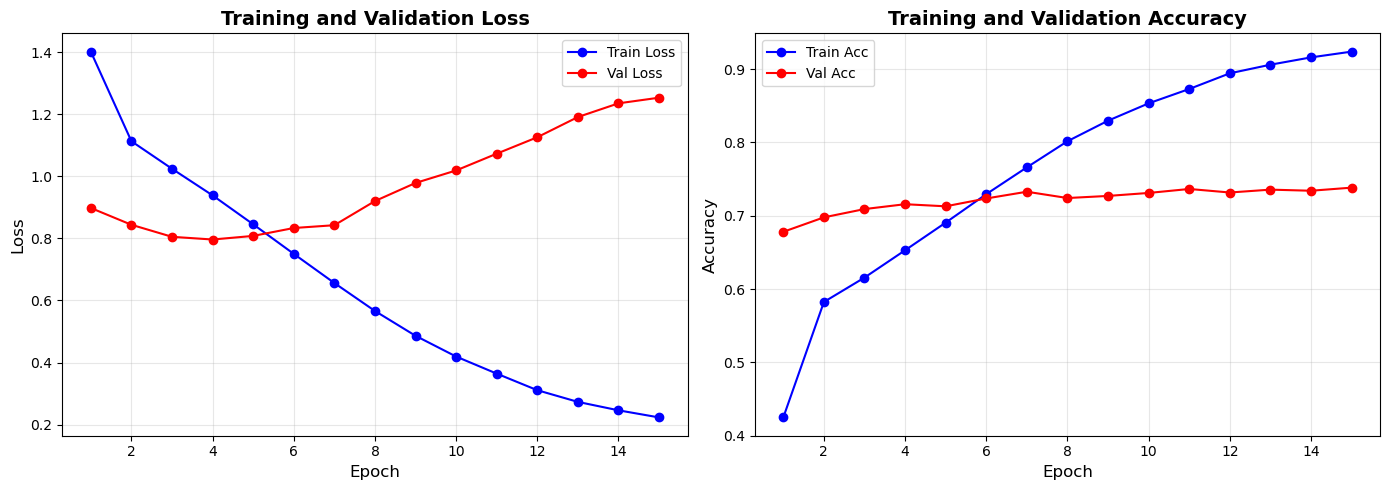


✅ 학습 곡선 저장: roberta_training_history.png


In [51]:
# ============================================
# Step 7: 학습 완료 및 최종 평가
# ============================================
print(f"\n{'='*70}")
print(f"✅ 학습 완료!")
print(f"{'='*70}")
print(f"🏆 최종 Best Validation Accuracy: {best_val_acc:.4f} ({best_val_acc*100:.2f}%)")
print(f"📊 학습된 Epochs: {len(history['train_loss'])}")
print(f"{'='*70}")

# 학습 곡선 시각화
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

epochs_range = range(1, len(history['train_loss']) + 1)

# Loss
ax1.plot(epochs_range, history['train_loss'], 'b-o', label='Train Loss')
ax1.plot(epochs_range, history['val_loss'], 'r-o', label='Val Loss')
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_title('Training and Validation Loss', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy
ax2.plot(epochs_range, history['train_acc'], 'b-o', label='Train Acc')
ax2.plot(epochs_range, history['val_acc'], 'r-o', label='Val Acc')
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.set_title('Training and Validation Accuracy', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('roberta_training_history.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ 학습 곡선 저장: roberta_training_history.png")


In [52]:
# ============================================
# 최종 평가
# ============================================
from sklearn.metrics import classification_report, confusion_matrix

print("\n최종 평가 중...")
model.load_state_dict(torch.load('best_roberta_model.pt'))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for batch in tqdm(val_loader, desc="최종 평가"):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        _, preds = torch.max(outputs.logits, dim=1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

emotion_names = [id_to_emotion[i] for i in range(6)]

print("\n" + "="*70)
print("📊 Classification Report:")
print("="*70)
print(classification_report(all_labels, all_preds, target_names=emotion_names))

print("\n" + "="*70)
print("📊 Confusion Matrix:")
print("="*70)
cm = confusion_matrix(all_labels, all_preds)
print(cm)

print("\n🎉 모든 과정 완료!")


최종 평가 중...


최종 평가: 100%|██████████| 208/208 [03:16<00:00,  1.06it/s]


📊 Classification Report:
               precision    recall  f1-score   support

        anger       0.75      0.73      0.74      1257
      anxiety       0.73      0.69      0.71      1112
embarrassment       0.65      0.71      0.68      1048
         hurt       0.64      0.64      0.64      1007
          joy       0.96      0.92      0.94      1213
      sadness       0.68      0.71      0.69      1003

     accuracy                           0.74      6640
    macro avg       0.73      0.73      0.73      6640
 weighted avg       0.74      0.74      0.74      6640


📊 Confusion Matrix:
[[ 921   87   72   82   16   79]
 [  77  764  124   65   10   72]
 [  54   79  746  100    8   61]
 [  85   55  120  640    4  103]
 [  19   18   17   21 1120   18]
 [  72   46   69   95   10  711]]

🎉 모든 과정 완료!
